In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'SpendingScore'}, inplace=True)
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


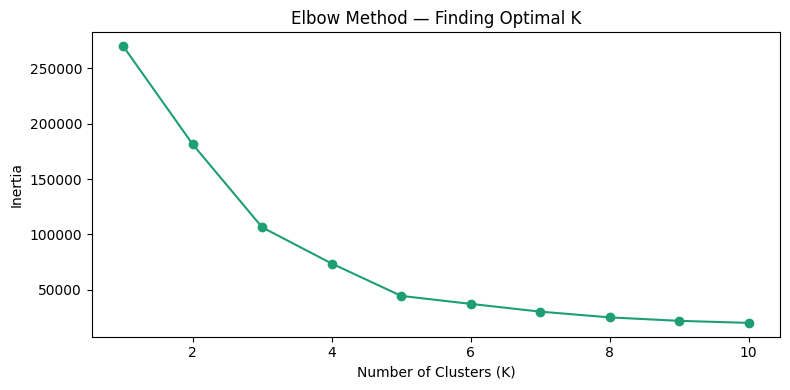

In [3]:
X = df[['Income', 'SpendingScore']]

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='#1D9E75')
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

In [4]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

score = silhouette_score(X, df['Cluster'])
print(f'Silhouette Score: {score:.2f}')

Silhouette Score: 0.55


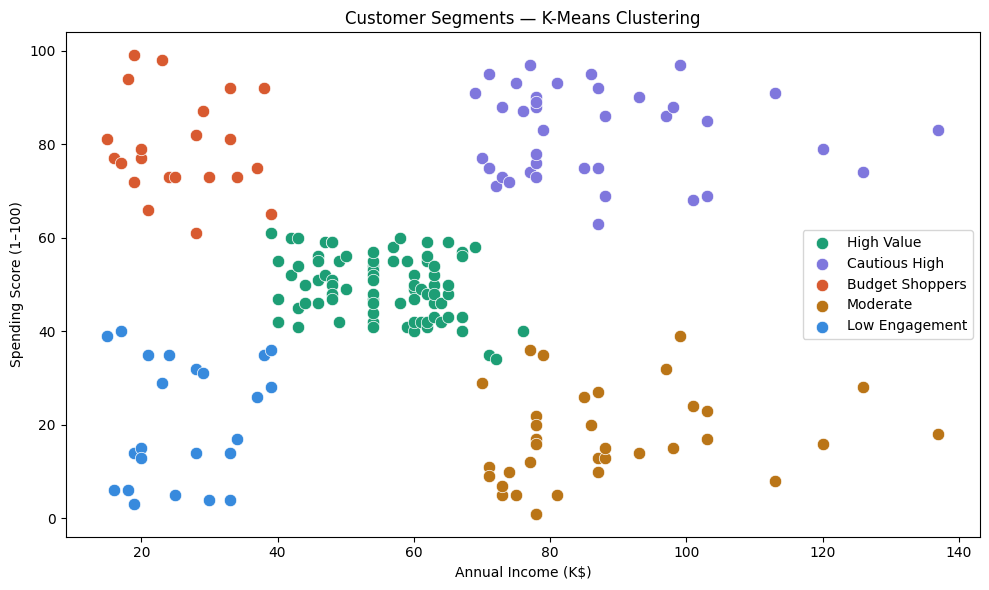

In [5]:
colors = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517', '#378ADD']
labels = ['High Value', 'Cautious High', 'Budget Shoppers', 'Moderate', 'Low Engagement']

plt.figure(figsize=(10, 6))
for i in range(5):
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['Income'], subset['SpendingScore'],
                color=colors[i], label=labels[i], s=80, edgecolors='white', linewidth=0.5)

plt.title('Customer Segments — K-Means Clustering')
plt.xlabel('Annual Income (K$)')
plt.ylabel('Spending Score (1–100)')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_plot.png', dpi=150)
plt.show()

In [6]:
summary = df.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Avg_Income=('Income', 'mean'),
    Avg_Spending=('SpendingScore', 'mean'),
    Avg_Age=('Age', 'mean')
).round(1)

summary['Label'] = labels
summary

,Count,Avg_Income,Avg_Spending,Avg_Age,Label
Cluster,,,,,
0,81,55.3,49.5,42.7,High Value
1,39,86.5,82.1,32.7,Cautious High
2,22,25.7,79.4,25.3,Budget Shoppers
3,35,88.2,17.1,41.1,Moderate
4,23,26.3,20.9,45.2,Low Engagement
